## Task 1 : Load and prepare data

Load the dog-cat-detection datasets. Resize the images in such a way that they have a fixed 112x112x3 format.


In [24]:
!pip install torchsummary

In [20]:
#Datasets
from torchvision import datasets, transforms
from torch.utils.data import Dataset, Subset, DataLoader
import kagglehub
# Imports for network
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.transforms import v2
from torchsummary import summary
from torchvision import tv_tensors
#Imports for metrics caluclation/visualization
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
#Other imports
import numpy as np
from tqdm import tqdm

In [5]:
import os
import glob
import torch
import xml.etree.ElementTree as ET
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("andrewmvd/dog-and-cat-detection")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'dog-and-cat-detection' dataset.
Path to dataset files: /kaggle/input/dog-and-cat-detection


Visualize cat-dog dataset

In [ ]:
INPUT_IMG_SZ = 112      #resize to 112x112x3

IMG_DIR = os.path.join(path, "images")
ANNOTATION_DIR = os.path.join(path, "annotations")


class CatDogDataset(Dataset):
    def __init__(self, img_dir, ann_dir, transform=None):
        self.img_dir = img_dir
        self.ann_dir = ann_dir
        self.transform = transform
        self.img_files = sorted(glob.glob(os.path.join(img_dir, "*.png")))
        self.ann_files = sorted(glob.glob(os.path.join(ann_dir, "*.xml")))
        self.label_map = {"cat": 0, "dog": 1}  # Label mapping

    def parse_annotation(self, ann_path):
        tree = ET.parse(ann_path)
        root = tree.getroot()
        width = int(root.find("size/width").text)
        height = int(root.find("size/height").text)
        objects = []

        for obj in root.findall("object"):
            name = obj.find("name").text
            xmin = int(obj.find("bndbox/xmin").text)
            ymin = int(obj.find("bndbox/ymin").text)
            xmax = int(obj.find("bndbox/xmax").text)
            ymax = int(obj.find("bndbox/ymax").text)

            label = self.label_map.get(name, -1)  # Default to -1 if unknown label
            objects.append({"label": label, "bbox": [xmin, ymin, xmax, ymax]})

        return width, height, objects

    def __len__(self):
        return len(self.img_files)

    def __getitem__(self, idx):
        img_path = self.img_files[idx]
        ann_path = self.ann_files[idx]

        image = Image.open(img_path).convert("RGB")
        width, height, objects = self.parse_annotation(ann_path)

        scaler_x = width / INPUT_IMG_SZ
        scaler_y = height / INPUT_IMG_SZ

        bboxes = []
        for obj in objects:
            xmin = obj['bbox'][0] / scaler_x
            ymin = obj['bbox'][1] / scaler_y
            xmax = obj['bbox'][2] / scaler_x
            ymax = obj['bbox'][3] / scaler_y
            bboxes.append([xmin, ymin, xmax, ymax])  # in your assignment 4, you need to convert bbox into [x, y, w, h] and value range [0, 1]

        bboxes = torch.tensor(bboxes, dtype=torch.float32)
        labels = torch.tensor([obj["label"] for obj in objects], dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, bboxes, labels


# Define transformations
transform = T.Compose([
    T.Resize((INPUT_IMG_SZ, INPUT_IMG_SZ)),
    T.ToTensor()
])

# Initialize dataset and dataloader
dataset = CatDogDataset(img_dir=IMG_DIR, ann_dir=ANNOTATION_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True, collate_fn=lambda x: tuple(zip(*x)))

# Function to visualize a batch
def visualize_batch(dataloader):
    images, bboxes, labels = next(iter(dataloader))
    fig, axes = plt.subplots(1, len(images), figsize=(15, 5))

    if len(images) == 1:
        axes = [axes]

    for i, (img, bbox, label) in enumerate(zip(images, bboxes, labels)):
        img = img.permute(1, 2, 0).numpy()
        axes[i].imshow(img)

        for box, lbl in zip(bbox, label):
            xmin, ymin, xmax, ymax = box.tolist()
            rect = patches.Rectangle((xmin, ymin), xmax - xmin, ymax - ymin,
                                     linewidth=2, edgecolor='r', facecolor='none')
            axes[i].add_patch(rect)
            axes[i].text(xmin, ymin - 5, f'Label: {lbl.item()}', color='red', fontsize=10,
                         bbox=dict(facecolor='white', alpha=0.5))
        axes[i].axis('off')

    plt.show()


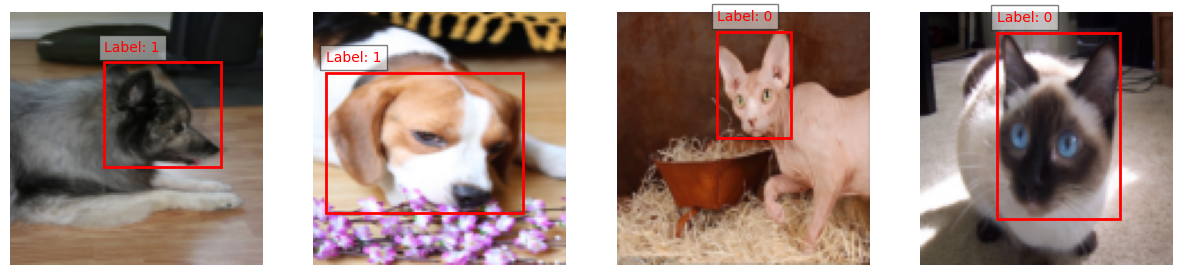

In [7]:
# Visualize a batch
visualize_batch(dataloader)

Split into test and training data

In [8]:
labels = []
for ann_path in dataset.ann_files:
    _, _, obj = dataset.parse_annotation(ann_path)
    
    label = obj[0]["label"]
    labels.append(label)

In [10]:
indices = list(range(len(dataset)))

train_idx, val_idx = train_test_split(
    indices,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

In [11]:
train_set = Subset(dataset, train_idx)
val_set = Subset(dataset, val_idx)

In [12]:
train_data = DataLoader(train_set, batch_size = 32, shuffle = True, pin_memory = True, collate_fn=lambda x: tuple(zip(*x)))
val_data = DataLoader(val_set, batch_size = 32, shuffle = False, pin_memory = True, collate_fn=lambda x: tuple(zip(*x)))

## Task 2 : Develop the architecture

<li> Your network contains the layers below. The output is similar to the YOLOv1 output, with a 7x7 spatial grid but with B=1 detections per cell, and only C=2 classes.</li>
<li>You can decide the type of pooling, activation functions, and whether or not to use dropout and batch normalization.</li>

Pay attention to the activation function of the output layer. At this point, we're not using non-maximum suppression. Your network should have approximately 1M parameters.

In [13]:
class ObjectDetector(nn.Module):
    #(N - F + 2*P) / S + 1
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels = 3, out_channels = 16, kernel_size = 3, stride = 1, padding=1, padding_mode='zeros')
        #input size: 3x112x112 -> output size: 112 - 3 + 2 + 1 = 16 x 112 x 112
        self.batch1 = nn.BatchNorm2d(num_features = self.conv1.out_channels)
        self.pool1 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0)
        #input size: 16 x 112 x 112 -> output size: 16 x 56 x 56
        
        self.conv2 = nn.Conv2d(in_channels = self.conv1.out_channels, out_channels = 32, kernel_size = 3, stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 16 x 56 x 56 -> output size: 32 x 56 x 56
        self.batch2 = nn.BatchNorm2d(num_features = self.conv2.out_channels)
        self.pool2 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0)
        # input size: 32 x 56 x 56 -> output size: 32 x 28 x 28

        self.conv3 = nn.Conv2d(in_channels = self.conv2.out_channels, out_channels = 64, kernel_size = 3 ,stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 32 x 28 x 28 -> output size: 64 x 28 x 28
        self.batch3 = nn.BatchNorm2d(num_features = self.conv3.out_channels)
        self.pool3 = nn.MaxPool2d(kernel_size = 2, stride = 2, padding = 0)
        #input size: 64 x 28 x 28 -> output size: 64 x 14 x 14

        self.conv4 = nn.Conv2d(in_channels = self.conv3.out_channels, out_channels = 64, kernel_size = 3, stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 64 x 28 x 28 -> output size: 64 x 28 x 28
        self.batch4 = nn.BatchNorm2d(num_features = self.conv4.out_channels)
        self.pool4 = nn.MaxPool2d(kernel_size=2, stride = 2, padding = 0)
        #input size: 64 x 14 x 14 -> output size: 64 x 7 x 7

        self.conv5 = nn.Conv2d(in_channels = self.conv4.out_channels, out_channels = 32, kernel_size = 3, stride = 1, padding = 1, padding_mode = 'zeros')
        #input size: 64 x 7 x 7 -> output size: 32 x 7 x 7
        self.batch5 = nn.BatchNorm2d(num_features = self.conv5.out_channels)
        
        self.flatten = nn.Flatten()

        self.drop = nn.Dropout(p = 0.5)
        self.full = nn.Linear(in_features = 32*7*7, out_features = 512)
        self.out = nn.Linear(in_features = self.full.out_features, out_features = 343)

    def forward(self, x):
        x = self.conv1(x)
        x = self.batch1(x)
        x = F.relu(x)
        x = self.pool1(x)
        
        x = self.conv2(x)
        x = self.batch2(x)
        x = F.relu(x)
        x = self.pool2(x)

        x = self.conv3(x)
        x = self.batch3(x)        
        x = F.relu(x)
        x = self.pool3(x)
        
        x = self.conv4(x)
        x = self.batch4(x)
        x = F.relu(x)
        x = self.pool4(x)

        x = self.conv5(x)

        x = self.batch5(x)
        x = F.relu(x)
        x = self.flatten(x)
        x = self.drop(x)
        x = self.full(x)
        x = F.relu(x)
        x = self.out(x)
        x = torch.sigmoid(x)

        return x

In [14]:
model = ObjectDetector()
total_params = sum(p.numel() for p in model.parameters())
print(f"Total parameters: {total_params}")

Total parameters: 1058679


In [15]:
class YOLOLoss(nn.Module):
    def __init__(self, batch_size = 32, grid_size = 7):
        super().__init__()
        self.batch = batch_size
        self.grid = grid_size

    def forward(self, pred, target, weight_coord = 5, weight_size = 5, weight_conf_yes = 1, weight_conf_no = 0.5, weight_class = 1):
        # Convert the flattened tensor from 343 to 7 x 7 x 7
        pred = torch.reshape(pred, (-1, self.grid, self.grid, 7))
        target = torch.reshape(target, (-1, self.grid, self.grid, 7))

        #Create a mask to detect where the object is by looking at the confidence (index 4)
        #Store both the mask if there is the object or if there is not
        mask_yes = target[:, :, :, 4] == 1
        mask_no = ~mask_yes

        #Create the yololoss with 5 terms. take difference x_c and y_c
        pred_center = pred[mask_yes, 0:2]
        target_center = target[mask_yes, 0:2]
        coordinate_loss = torch.nn.functional.mse_loss(pred_center, target_center)

        # size loss
        # we use clamp because torch.sqrt could produce nan if predictions are negativre
        pred_wh = torch.sqrt(torch.clamp(pred[mask_yes, 2:4], min=1e-6))
        target_wh = torch.sqrt(torch.clamp(target[mask_yes, 2:4], min=1e-6))
        size_loss = torch.nn.functional.mse_loss(pred_wh, target_wh)

        #confidence loss for cells where there is the target
        pred_conf_yes = pred[mask_yes, 4]
        target_conf_yes = target[mask_yes, 4]
        confidence_loss_yes = torch.nn.functional.mse_loss(pred_conf_yes, target_conf_yes)

        #confidence loss for cells whete there is no target
        pred_conf_no = pred[mask_no, 4]
        target_conf_no = target[mask_no, 4]
        confidence_loss_no = torch.nn.functional.mse_loss(pred_conf_no, target_conf_no)

        #loss for the correct class prediction
        pred_class = pred[mask_yes, 5:7]
        target_class = target[mask_yes, 5:7]
        class_loss = torch.nn.functional.mse_loss(pred_class, target_class)

        total_loss = weight_coord * coordinate_loss
        total_loss += weight_size * size_loss
        total_loss += weight_conf_yes * confidence_loss_yes
        total_loss += weight_conf_no * confidence_loss_no
        total_loss += weight_class * class_loss

        return total_loss, coordinate_loss, size_loss, confidence_loss_yes, confidence_loss_no, class_loss

In [26]:
from sklearn.metrics import recall_score, precision_score, precision_recall_curve, f1_score

class TrainDetector(nn.Module):
    def __init__(self, model, optimizer, loss, device, data_loader, val_loader, batch_transform = None):
        super().__init__()
        self.model = model
        self.opt = optimizer
        self.loss = loss
        self.device = device
        self.data = data_loader
        self.val = val_loader
        self.batch_transform = batch_transform
    
    def _change_bbox(self, bbox, labels, grid_size = 7, im_size = 112):
        """
            Function to change the format of the bounding boxes from [xmin, ymin, xmax, ymax]
            to [xcenter, ycenter, width, height, confidence, one hot encoding].
            param: bbox (list): list containing the bbox coordinates in the format [xmin, ymin, xmax, ymax]
            param: labels (list): list of the labels for each bbox
            param: grid_size (int): size of the grid in which to divide the image
            param: im_size (int): size of the image
            returns: new_bbox (list): flattened version of the tensor
        """
        new_bbox = torch.zeros(grid_size, grid_size, 7, device = self.device)
        # Find the new values for the bbox expressed as the centre of the bbox
        # and the width and height, along with confidence and class
        for box, label in zip(bbox, labels):
            x_c = (box[0] + box[2]) / 2 
            y_c = (box[1] + box[3]) / 2 
            norm_xc = x_c / im_size
            norm_yc = y_c / im_size
            w = (box[2] - box[0]) / (im_size)
            h = (box[3] - box[1]) / (im_size)
            # We find where in the grid the object actually is
            # by multiplying the normalized centre coordinates by the grid size
            # Since this represents a fraction of the grid. We take the int
            col = min(int(norm_xc * grid_size), grid_size - 1)
            row = min(int(norm_yc * grid_size), grid_size - 1)

            #The cell with the image has 7 values
            new_bbox[row, col, 0] = (norm_xc * grid_size) - col
            new_bbox[row, col, 1] = (norm_yc * grid_size) - row
            new_bbox[row, col, 2] = w
            new_bbox[row, col, 3] = h
            new_bbox[row, col, 4] = 1 # confidence
            if label == 0:
                new_bbox[row, col, 5] = 1
                new_bbox[row, col, 6] = 0
            elif label == 1:
                new_bbox[row, col, 5] = 0
                new_bbox[row, col, 6] = 1
        return new_bbox.flatten()

    def _forward_pass(self, data, bboxes, labels):
        if self.model.training and self.batch_transform:
            aug_data = []
            aug_bbox = []
            for img, bbox in zip(data, bboxes):
                tv_box = tv_tensors.BoundingBoxes(bbox, format="XYXY", canvas_size=(112, 112))
                aug_img, aug_box = self.batch_transform(img, tv_box)
                aug_data.append(aug_img)
                aug_bbox.append(aug_box)
            data = aug_data
            bboxes = aug_bbox

        data = torch.stack(data).to(self.device)
        target = torch.stack([
            self._change_bbox(bbox, label)
            for bbox, label in zip(bboxes, labels)
        ]).to(self.device)

        pred = self.model(data)
        loss, *components = self.loss(pred, target)
        return loss, components

    def validate(self):
        self.model.eval()
        val_losses = []
        comp_losses = [[] for _ in range(5)]
        with torch.no_grad():
            for (data, bbox, label) in self.val:
                val_loss, components = self._forward_pass(data, bbox, label)
                val_losses.append(val_loss.item())
                for key, comp in enumerate(components):
                    comp_losses[key].append(comp.item())

        self.model.train()
        return np.mean(val_losses), [np.mean(c) for c in comp_losses]

    def _print_loss(self, loss, val_loss):
        """
        Function to plot the training accuracy vs validation accuracy and the
        training loss vs validation loss. This is used when trainign and is
        activated by the plot flag.
        param: accuracy (list): list of training accuracy values per epoch
        param: loss (list): list of training loss values per epoch
        param: val_accuracy (list): list of validation accuracy values per epoch
        param: val_loss (list): list of validation loss values per epoch
        """
        epochs_range = range(len(loss))
        fig, ax = plt.subplots(1, figsize = (12,6))

        ax.plot(epochs_range, loss, label = 'Training')
        ax.plot(epochs_range, val_loss, label = 'Validation')
        ax.set_title("Loss")
        ax.set_xlabel("Epochs")
        ax.set_ylabel("Loss")
        ax.legend()

        plt.suptitle(f"{type(self.model).__name__}")
        plt.tight_layout()
        plt.show()
    
    def _print_component_losses(self, train_comps, val_comps, comp_names):
        """
            Function to print the losses for the componets of the YOLOLOSS class.
            param: train_comps (dict): training loss for each component
            param: val_comps (dict): validation loss for each component
            param: comp_names (list): list of name sof the components
        """
        fig, axs = plt.subplots(5,1, figsize = (10,20))
        for ax, name in zip(axs, comp_names):
            ax.plot(train_comps[name], label = 'training')
            ax.plot(val_comps[name], label = 'validation')
            ax.set_title(name)
            ax.set_xlabel('Epochs')
            ax.set_ylabel('Loss')
            ax.legend()

        plt.suptitle('Loss Components')
        plt.tight_layout()
        plt.show()

    def train(self, epochs, epsilon = 1e-6, plot = False, verbose = False):
        avg_losses = []
        #For each epoch
        val_losses = []
        component_names = ['Coordinate', 'Size', 'Confidence (obj)', 'Confidence (no obj)', 'Class']
        train_components = {n: [] for n in component_names}
        val_components = {n: [] for n in component_names}

        scheduler = torch.optim.lr_scheduler.StepLR(self.opt, step_size=10, gamma=0.5)
        for epoch in range(epochs):
            if verbose:
                print(f"Started training on epoch {epoch}")
            self.model.train()
            losses = []
            batch_comps = [[] for _ in range(5)]
            #For each batch
            for i, (data, bbox, label) in enumerate(tqdm(self.data, f"Training epoch {epoch + 1}")): 
                self.opt.zero_grad()
                loss, components = self._forward_pass(data, bbox, label)
                loss.backward()
                self.opt.step()
                losses.append(loss.item())
                if verbose:
                    print(f"Loss for batch {i + 1} in epoch {epoch}: {loss}")
                for key, comp in enumerate(components):
                    batch_comps[key].append(comp.item())
            scheduler.step()
            val_loss, val_comps = self.validate()

            if verbose:
                print(f"Validation loss in epoch {epoch}: {val_loss}")
            
            for key, name in enumerate(component_names):
                train_components[name].append(np.mean(batch_comps[key]))
                val_components[name].append(val_comps[key])
            
            val_losses.append(val_loss)
            avg_loss = np.mean(losses)
            avg_val_loss = np.mean(val_losses)

            avg_losses.append(avg_loss)

            if len(val_losses) > 1 and abs(val_losses[-1] - val_losses[-2]) < epsilon:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                break

            if verbose:
                print(f"Average training loss across epochs: {avg_loss}")
                print(f"Average validation loss across epochs: {avg_val_loss}")
            
        if plot:
            self._print_loss(avg_losses, val_losses)
            self._print_component_losses(train_components, val_components, component_names)

        return avg_loss, avg_val_loss

    def _decode_predictions(self, pred, conf_thresh=0.5, grid_size=7, img_size=112):

        """
        Converts values of model output to bounding boxes in image coordinates + confidence score + class (label)
        Based on the model output, 7x7 grid, with each cell predicting [x, y, w, h, confidence, class1, class2]
        """

        boxes = []

        for i in range(grid_size):
                for j in range(grid_size):
                    cell = pred[i,j]

                    confidence = cell[4].item() 
                    if confidence < conf_thresh:
                        continue

                    x,y,width,height = cell[0:4] 

                    x_center = (j + x.item()) / grid_size * img_size
                    y_center = (i + y.item()) / grid_size * img_size
                    width = width.item() * img_size
                    height = height.item() * img_size

                    xmin = x_center - width / 2
                    ymin = y_center - height / 2
                    xmax = x_center + width / 2
                    ymax = y_center + height / 2

                    class_probs = cell[5:7] 
                    label = torch.argmax(class_probs).item()

                    boxes.append({
                        "bbox": [xmin, ymin, xmax, ymax],
                        "score": confidence,
                        "label": label
                    })

        return boxes

    def _iou(self, box1, box2):

        """
        Intersection Over Union: given two bounding boxes box1 and box2, 
        IoU = (box1 ∩ box2) / (box1 ∪ box2)
        """
        x1 = max(box1[0], box2[0])
        y1 = max(box1[1], box2[1])
        x2 = min(box1[2], box2[2])
        y2 = min(box1[3], box2[3])

        intersection_area = max(0, x2-x1) * max(0, y2-y1)

        box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
        box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])

        union_area = box1_area + box2_area - intersection_area

        return 0 if union_area == 0 else intersection_area / union_area
    
    
    def _nms(self, boxes, iou_threshold = 0.5):

        if len(boxes) == 0:
            return []

        # sort boxes by confidence score (from highest)
        boxes = sorted(boxes, key=lambda x: x["score"], reverse=True)
        keep = []

        while boxes:
            best = boxes.pop(0) # extract the box with highest confidence score
            keep.append(best)

            remaining = []
            for box in boxes: 
                if box["label"] != best["label"]:
                    remaining.append(box)
                elif self._iou(box["bbox"], best["bbox"]) < iou_threshold:
                    remaining.append(box)

            boxes = remaining

        return keep


    def evaluate(self, threshold=0.5, grid_size=7, conf_matrix=False, verbose=False, use_nms = True):
        self.model.eval()

        results = {}
        tp = {0: 0, 1: 0}
        fp = {0: 0, 1: 0}
        fn = {0: 0, 1: 0}

        all_pred_labels = []
        all_true_labels = []

        with torch.no_grad():
            for (data, bboxes, labels) in self.val:
                data = torch.stack(data).to(self.device)
                preds = self.model(data).reshape(-1, grid_size, grid_size, 7)

                for i in range(len(preds)):
                    pred = preds[i]

                    boxes = self._decode_predictions(pred, conf_thresh=threshold)
                    boxes = sorted(boxes, key=lambda x: x["score"], reverse=True)
                    if use_nms:
                        boxes = self._nms(boxes)

                    gt_boxes = []
                    for box, label in zip(bboxes[i], labels[i]):
                        xmin, ymin, xmax, ymax = box.tolist()
                        gt_boxes.append({
                            "bbox": [xmin, ymin, xmax, ymax],
                            "label": label.item(),
                            "matched": False
                        })

                    for pred_box in boxes:
                        best_iou = 0
                        best_gt = None

                        for gt in gt_boxes:
                            if gt["label"] != pred_box["label"] or gt["matched"]:
                                continue

                            iou = self._iou(pred_box["bbox"], gt["bbox"])
                            if iou > best_iou:
                                best_iou = iou
                                best_gt = gt

                        if best_iou > 0.5:
                            tp[pred_box["label"]] += 1
                            best_gt["matched"] = True
                            all_pred_labels.append(pred_box["label"])
                            all_true_labels.append(best_gt["label"])
                        else:
                            fp[pred_box["label"]] += 1
                            all_pred_labels.append(pred_box["label"])
                            all_true_labels.append(-1) 

                    for gt in gt_boxes:
                        if not gt["matched"]:
                            fn[gt["label"]] += 1
                            all_pred_labels.append(-1)  # missed prediction
                            all_true_labels.append(gt["label"])

        if conf_matrix and len(all_true_labels) > 0:
            cm = confusion_matrix(all_pred_labels, all_true_labels, labels=[0, 1, -1])
            mask = np.zeros_like(cm, dtype=bool)
            mask[2, 2] = True  # exclude None-None cell
            sns.heatmap(cm, annot=True, fmt='d', mask = mask,
                        xticklabels=["Cat", "Dog", "None"],
                        yticklabels=["Cat", "Dog", "None"])
            plt.show()

        for c in [0, 1]:
            precision = tp[c] / (tp[c] + fp[c] + 1e-8)
            recall    = tp[c] / (tp[c] + fn[c] + 1e-8)
            f1        = 2 * precision * recall / (precision + recall + 1e-8)
            results[c] = (precision, recall, f1)

        if verbose:
            print(f"Results per class: {results}")

        # if compute_map:
        #     mAP = self._comp_mAP(threshold)
        #     return results, mAP

        return results

    def _comp_mAP(self, plot_curve = False, use_nms = True, verbose = False):
        thresholds = np.linspace(0.01, 0.99, 50) 
        best_thresh = 0.5
        best_f1 = 0

        precisions = {0: [], 1: []}
        recalls = {0: [], 1: []}

        for thresh in thresholds:
            results = self.evaluate(threshold=thresh, use_nms = use_nms)
            avg_f1 = np.mean([results[c][2] for c in [0,1]])
            if avg_f1 > best_f1:
                best_f1 = avg_f1
                best_thresh = thresh
        
            for c in [0, 1]:
                precision, recall, _ = results[c]
                precisions[c].append(precision)
                recalls[c].append(recall)
        
        if verbose:
            print(f'Best Threshold {best_thresh:.2f}, Average f1: {best_f1:.3f}')

        self.evaluate(threshold = best_thresh, conf_matrix=True, verbose = True)
        aps = []
        for c in [0, 1]:
            r = np.array(recalls[c])
            p = np.array(precisions[c])

            idx = np.argsort(r)
            aps.append(np.trapezoid(p[idx], r[idx]))

        mAP = np.mean(aps)

        if plot_curve:
            fig, axes = plt.subplots(1, 2, figsize=(12, 5))
            for c in [0, 1]:
                axes[c].plot(recalls[c], precisions[c])
                axes[c].set_title(f"Class {c}")
                axes[c].set_xlabel("Recall")
                axes[c].set_ylabel("Precision")
            plt.suptitle(f"mAP: {mAP:.3f}")
            plt.show()

        return mAP

    def test(self, test_loader, use_nms = True):
        self.model.eval()
        test_losses = []
        #results = []
        with torch.no_grad():
            for (data, bbox, label) in test_loader:
                test_loss, _ = self._forward_pass(data, bbox, label)
                test_losses.append(test_loss.item())
            original_val = self.val

        self.val = test_loader
        mAP = self._comp_mAP(plot_curve=True, use_nms = use_nms)
        self.val = original_val  

        return mAP

## Task 3 : Train your object detector model

<li>Use the dog-cat-detection train and val sets to train your network from scratch.</li>
<li>use early stopping on the loss of your val set. </li>
<li>Use the same five losses as in the original YOLOv1 paper, with the same weights. </li>
<li>You are free to choose your hyperparameters, including batch size, optimizer and learning rate.</li>

In [27]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = ObjectDetector().to(device)
epochs = 100
loss_function = YOLOLoss()
learning_rate = 3e-4
optimizer = torch.optim.Adam(params = model.parameters(), lr = learning_rate)

In [28]:
batch_augmenter = v2.Compose([
    v2.RandomHorizontalFlip(p=0.5),                    
    v2.RandomResizedCrop(size=(112, 112), antialias=True, scale=(0.8, 1.0)), 
    v2.RandomAffine(degrees=15, translate=(0.1, 0.1)), 
    v2.ColorJitter(brightness=0.2, contrast=0.2)       
])

In [29]:
summary(model, (3,112,112))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 112, 112]             448
       BatchNorm2d-2         [-1, 16, 112, 112]              32
         MaxPool2d-3           [-1, 16, 56, 56]               0
            Conv2d-4           [-1, 32, 56, 56]           4,640
       BatchNorm2d-5           [-1, 32, 56, 56]              64
         MaxPool2d-6           [-1, 32, 28, 28]               0
            Conv2d-7           [-1, 64, 28, 28]          18,496
       BatchNorm2d-8           [-1, 64, 28, 28]             128
         MaxPool2d-9           [-1, 64, 14, 14]               0
           Conv2d-10           [-1, 64, 14, 14]          36,928
      BatchNorm2d-11           [-1, 64, 14, 14]             128
        MaxPool2d-12             [-1, 64, 7, 7]               0
           Conv2d-13             [-1, 32, 7, 7]          18,464
      BatchNorm2d-14             [-1, 3

In [ ]:
trainer = TrainDetector(model, optimizer, loss_function, device, train_data, val_data, batch_transform=batch_augmenter)
avg_loss, avg_val_loss = trainer.train(epochs, plot = True)

Training epoch 52:   9%|▊         | 8/93 [00:02<00:29,  2.92it/s]

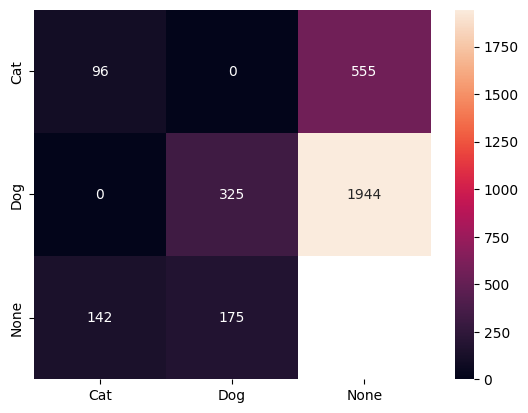

Results per class: {0: (0.14746543778575322, 0.40336134452086714, 0.21597299944883158), 1: (0.1432349052439699, 0.649999999987, 0.23474178107656601)}


In [ ]:
results_base = trainer.evaluate(
    threshold=0.5,
    conf_matrix=True,
    verbose=True,
    use_nms = False
)

In [ ]:
results_nms = trainer.evaluate(
    threshold=0.5,
    conf_matrix=True,
    verbose=True,
    use_nms = True
)

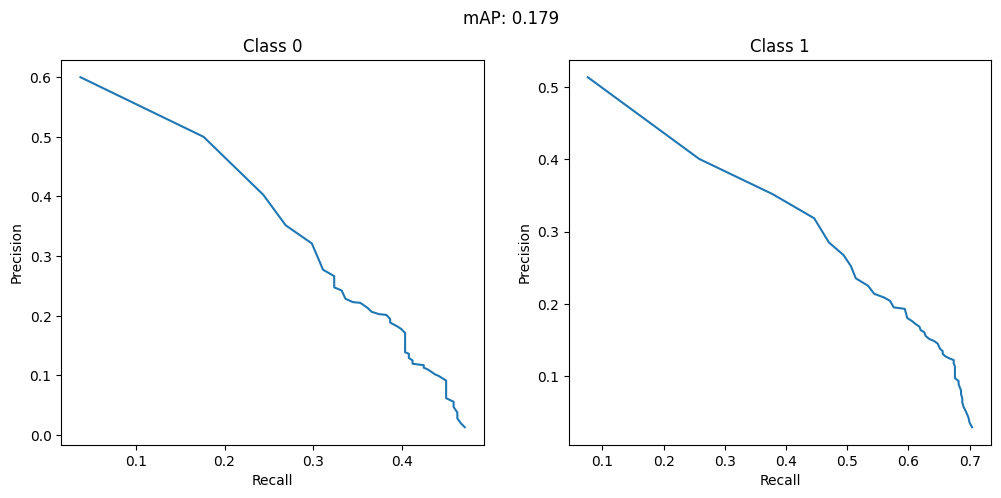

In [ ]:
mAP = trainer._comp_mAP(plot_curve=True, use_nms = )

In [18]:
print(f"Mean Average Precision: {mAP * 100:.2f}%")

Mean Average Precision: 17.87%
